In [51]:
import numpy as np
np.set_printoptions(suppress=True, precision=4)
from itertools import pairwise
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"
import dtreeviz

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_iris
from sklearn.datasets import load_diabetes


# Supervised Data Algorithms
## 1. Linear Regression

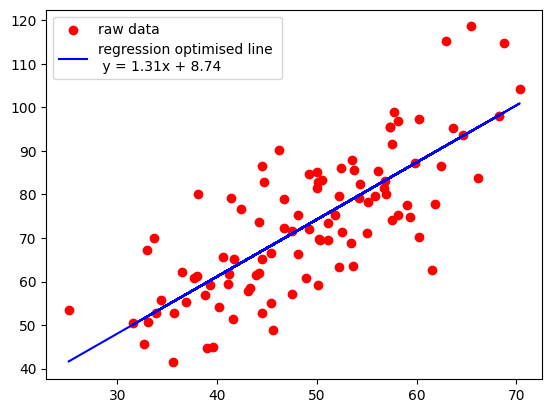

y_values : [ 68.77759598  62.5623823   71.54663223  87.23092513  78.21151827
  79.64197305  59.17148932  75.3312423   71.30087989  55.16567715
  82.47884676  62.00892325  75.39287043  81.43619216  60.72360244
  82.89250373  97.37989686  48.84715332  56.87721319  83.87856466
 118.5912173   57.25181946  51.39174408  75.38065167  74.76556403
  95.45505292  95.22936602  79.05240617  83.43207142  63.35879032
  41.4128853   76.61734128  96.76956643  74.08413012  66.58814441
  77.76848242  50.71958891  62.12457082  60.81024665  52.68298337
  58.56982472  82.90598149  61.4247098  115.2441528   45.57058882
  54.0840548   87.99445276  52.72549438  93.57611869  80.16627545
  65.10171157  65.56230126  65.28088692  73.43464155  71.13972786
  79.10282968  86.52053844  84.74269781  59.35885025  61.68403752
  69.84760416  86.09829121  59.10883927  69.89968164  44.86249071
  85.49806778  95.53668685  70.25193442  52.72173496  50.39267014
  63.64239878  72.24725107  57.81251298 104.25710159  86.64202032

In [170]:
# 1. gradient descent linear regression fn = linear relationship btw 2 datsets (X and Y), cotinuous output 
'''
x = np.array([1,2,3,4,5])
y = np.array([5,7,9,11,13])
'''
df = pd.read_csv('./public/gd.csv')
x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

def graddes(x, y, l_rate, epochs):
    m = c = 0 
    n = len(x)
    mse = list()
    for i in range(epochs):
        y_pred = (m*x) + c #numpy array of all values
        cf = (1/n) * sum((y_pred - y)**2)
        grad_m = (2/n) * sum(-x*(y_pred - y))
        grad_c = (2/n) * sum(-1*(y_pred - y))

        m += l_rate * grad_m
        c += l_rate * grad_c
        if i % 100 == 0 or i == epochs - 1:
            mse.append(round(cf,6))
    is_decreasing = all(i >= j for i, j in pairwise(mse))
    return (y_pred, m, c) if is_decreasing else (np.zeros(n),0,0)

(y_pred, m, c) = graddes(x, y, l_rate=0.00029, epochs=100000)

plt.scatter(x,y,color="red", label="raw data")
plt.plot(x,y_pred,color="blue", label=f"regression optimised line \n y = {round(m,2)}x + {round(c,2)}")
plt.legend()
plt.show()

print(f"y_values : {y}")
print(f"y_pred : {y_pred}")

In [171]:
#model.fit(x.reshape(-1, 1), y) # x = [[1], [2], [3]] internally evaluated as a vertical column or 3 samples of feature x 
model = LinearRegression()
model.fit(x.reshape(-1,1),y)
print(f"y = {round(model.coef_[0], 2)}x + {round(model.intercept_, 2)}")

y = 1.29x + 9.91


In [179]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression() #linear regressor 
model.fit(x_train.reshape(-1,1),y_train)
y_pred = model.predict(x_test.reshape(-1,1))

#finding residuals (regrssion metrics)
print(f"Minimized mean-squared-error : {mean_squared_error(y_test, y_pred)}")
print("MAE", mean_absolute_error(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

model.predict([[5.9]]) #[ [5.9] ] represents the row 

Minimized mean-squared-error : 69.24927307794563
MAE 6.785645810167421
RMSE 8.321614811918757


array([20.84931717])

## 2. Classification

| Classifier | Internal Metric / Scoring Surface | Shape of Decision Boundary | Hyperparameters (What You Tune) | Learned Parameters (What the Model Finds) | Primary Evaluation Metrics |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | **Continuous Probability S-Curve** (squashed log-odds score) | **Straight Line / Flat Hyperplane** (slanted at an angle determined by weights) | `penalty` (L1/L2 regularization), `C` (inverse regularization strength), `solver` | Coefficients / Weights ($m_1, m_2, \dots$) and Bias / Intercept ($c$) | Accuracy, Precision, Recall, F1-Score, **ROC-AUC Score**, Log-Loss |
| **Decision Trees (ID3/CART)** | **Information Gain / Entropy Drops** (stepwise impurity reduction) | **Staircase / Boxy Rectilinear Grid** (always perpendicular to feature axes) | `max_depth`, `min_samples_split`, `criterion` (`entropy` or `gini`) | The exact feature thresholds at each node split (e.g., $\text{Age} > 32.4$) | Accuracy, Precision, Recall, F1-Score, Feature Importance |
| **Naive Bayes** | **Joint Posterior Probability** (product of individual conditional frequencies) | **Smoothly Curved or Linear** (Quadratic or Linear depending on feature variance) | `alpha` (Laplace smoothing parameter), `var_smoothing` (for Gaussian NB) | Class prior probabilities, feature means ($\mu$), and variances ($\sigma^2$) | Accuracy, Precision, Recall, F1-Score, Log-Loss |
| **Support Vector Machines (SVM)** | **Geometric Distance Margin** (distance to closest support vectors) | **Straight Line** (Linear kernel) or **Complex/Wrap-around Curves** (RBF) | `C` (penalty cost), `kernel` (linear, rbf, poly), `gamma` (kernel coefficient) | Support vector coordinates and their corresponding Lagrangian multiplier weights ($\alpha$) | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |
| **$K$-Nearest Neighbors ($K$-NN)** | **Local Neighborhood Density Vote** (distance-based grouping) | **Jagged, Irregular, and Fragmented Curves** (wraps tightly around local clusters) | `n_neighbors` ($K$ count), `metric` (Euclidean, Manhattan distance), `weights` | None! (It is an *instance-based* learner; it just stores the training raw data points) | Accuracy, Precision, Recall, F1-Score |

## 2.2. SVM - Multiclass classification

In [53]:
df = pd.read_csv("./public/iris.data")
le = LabelEncoder()
df["CLASS"] = le.fit_transform(df["CLASS"])
x_train, x_test, y_train, y_test = train_test_split(df[["SL", "SW", "PL", "PW"]], df["CLASS"], test_size=0.3, random_state=42, stratify=df["CLASS"])
model = SVC(kernel="linear") #linear (100%), rbf (95.55), sigmoid (4.44), poly (95.55)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(model.get_params()) # model hyperparameters
print(f"\n y_test : \n {y_test.values}\n y_pred : \n{y_pred}")

# evaluation metrics 
print("\nConfusion Matrix \n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f"Accuracy score : {accuracy_score(y_test, y_pred)*100}%")


{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

 y_test : 
 [2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]
 y_pred : 
[2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]

Confusion Matrix 
 [[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Accuracy score : 100.0%


## 2.1. Logistic Classification/Regression
$$S(z) = \frac{1}{1 + e^{-z}}$$
$$\sigma(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x)}}$$
$$\sigma(x) = \frac{1}{1 + e^{-(m_1x_1 + m_2x_2 + \dots + c)}}$$

Where:
*   **$S(z)$**: The final output probability (always constrained between $0$ and $1$).
*   **$e$**: Euler's constant (approximately $2.71828$).
*   **$z$**: The log-odds or raw score input from your linear equation (i.e., $z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots$).

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2964/2704000593.py:15: SyntaxWarning: invalid escape sequence '\s'
/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


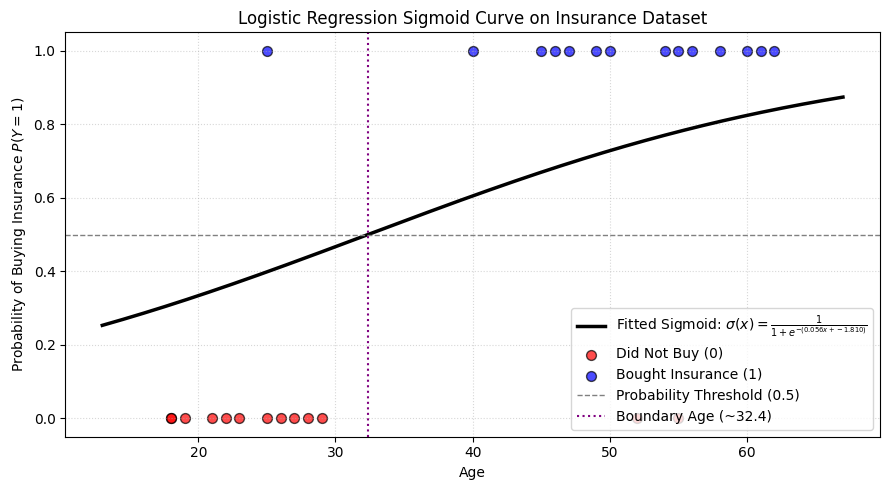

In [55]:
# Binomial Classification of single X (dimension)
df = pd.read_csv('./public/insurance_data.csv')
X = df[['age']]
y = df['bought_insurance']

model = LogisticRegression(solver='liblinear')
model.fit(X, y)
m = model.coef_[0][0]      # The slope parameter
c = model.intercept_[0]    # The intercept/bias parameter

# create a sigmoid decision boundary (probability curve / regression line) across the age range to plot the ideal curve
age_range = np.linspace(X['age'].min() - 5, X['age'].max() + 5, 500).reshape(-1, 1)
prob_curve = model.predict_proba(age_range)[:, 1]
plt.figure(figsize=(9, 5))
sigmoid_label = f"Fitted Sigmoid: $\sigma(x) = \\frac{{1}}{{1 + e^{{-({m:.3f}x + {c:.3f})}}}}$"
plt.plot(age_range, prob_curve, color='black', linewidth=2.5, label=sigmoid_label) ## Plot the continuous S-shaped Sigmoid Curve line

# Scatter actual test/data points at their true binary values (0 or 1)
plt.scatter(df[df['bought_insurance'] == 0]['age'], df[df['bought_insurance'] == 0]['bought_insurance'], 
            color='red', edgecolor='k', s=50, alpha=0.7, label='Did Not Buy (0)')
plt.scatter(df[df['bought_insurance'] == 1]['age'], df[df['bought_insurance'] == 1]['bought_insurance'], 
            color='blue', edgecolor='k', s=50, alpha=0.7, label='Bought Insurance (1)')

# Draw the 0.5 classification threshold boundary lines
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Probability Threshold (0.5)')

# Calculate the exact age where the model switches its prediction (z = 0)
m = model.coef_[0][0]
c = model.intercept_[0]
boundary_age = -c / m
plt.axvline(x=boundary_age, color='purple', linestyle=':', linewidth=1.5, label=f'Boundary Age (~{boundary_age:.1f})')

plt.xlabel('Age')
plt.ylabel('Probability of Buying Insurance $P(Y=1)$')
plt.title('Logistic Regression Sigmoid Curve on Insurance Dataset')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

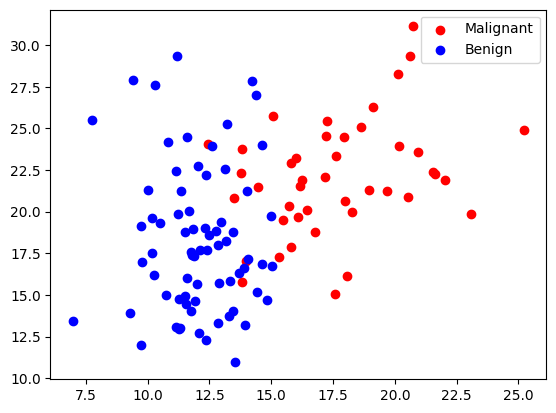

In [14]:
# Binary classification ie benign/malignant (signmoid decision boundary line) (Binary logistic regression)
# activation fn : signmoid
# Decision Boundary: By default, Scikit-learn uses a 0.5 threshold; if the predicted probability is >0.5>0.5, the model assigns the data point to class 1
# Logistic regression applies the sigmoid function to map linear outputs to a probability range between 0 and 1.
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#plotting cols/featues = Mean Radius (0) and Mean texture (1) features are X and Y axis - data distribution
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color="red", label="Malignant")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color="blue", label="Benign")
plt.legend()
plt.show()

In [10]:
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.96

Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



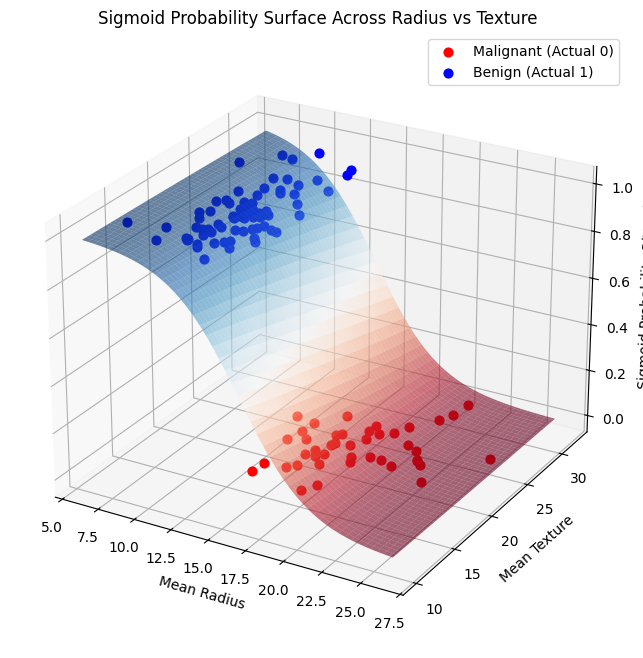

In [54]:
#data distribution of 2 features
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model ONLY on the first two features (Mean Radius and Mean Texture)
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train[:, :2], y_train)

# Create a 2D grid grid for your two features
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict sigmoid probabilities across the entire grid
# [:, 1] gives the probability of being Benign (1)
zz = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
zz = zz.reshape(xx.shape)

# Build the 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xx, yy, zz, cmap='RdBu', alpha=0.6, edgecolor='none') #Plot the continuous Sigmoid Curve surface

# Scatter actual test points (y_test sits on the 0 and 1 baselines)
ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], 0, color='red', s=40, label='Malignant (Actual 0)', depthshade=False)
ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], 1, color='blue', s=40, label='Benign (Actual 1)', depthshade=False)

# Labels and perspective adjustments
ax.set_xlabel('Mean Radius')
ax.set_ylabel('Mean Texture')
ax.set_zlabel('Sigmoid Probability P(Y=1)')
ax.set_title('Sigmoid Probability Surface Across Radius vs Texture')
ax.legend()

# Adjust the viewing angle to see the curve clearly
ax.view_init(elev=25, azim=-60)
plt.show()

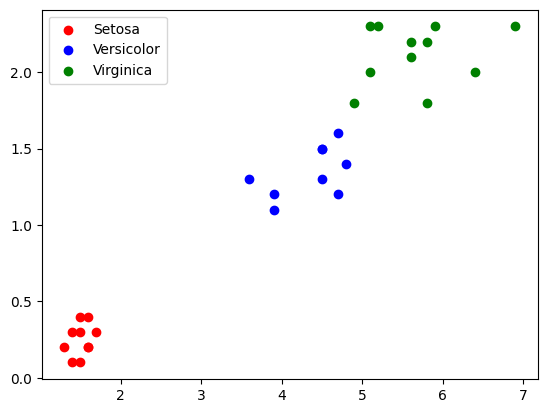

In [13]:
# Multi-class classification 
# Creates a binary classifier for each class against the others and models all class simulataniously using multiclass=multinomial (soft-max multinomial regression)
# activation function = softmax
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#plotting cols/featues = PL (2) and PW (3) features are X and Y axis - data distribution
plt.scatter(X_test[y_test == 0, 2], X_test[y_test == 0, 3], color="red", label="Setosa")
plt.scatter(X_test[y_test == 1, 2], X_test[y_test == 1, 3], color="blue", label="Versicolor")
plt.scatter(X_test[y_test == 2, 2], X_test[y_test == 2, 3], color="green", label="Virginica")
plt.legend()
plt.show()

In [12]:
model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 1.00


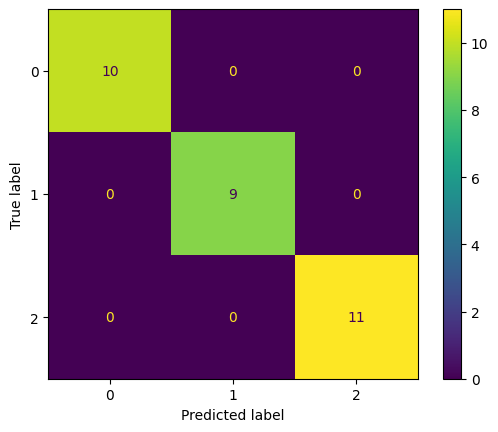

In [49]:
y_pred = model.predict(X_test)
print(f"Accuracy: {model.score(X_test, y_test):.2f}")
#sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=model.classes_)
disp.plot()
plt.show()

## 2.3. Decision Tree & Random Forest (Classifier & Regeressor)

This document outlines the core formulas for **Entropy** and **Information Gain** used to build a Decision Tree, mapped directly to your `salary.csv` dataset. It concludes with a minimal mathematical representation of how a decision is made for a specific sample.


#### Entropy (Measure of Impurity)
For a dataset $S$ containing a categorical target variable with multiple classes, the general Entropy formula is:

$$\text{Entropy}(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

Where:
* $c$ is the number of classes in the target variable (`salary_more_then_100k` $\rightarrow$ classes: `0` and `1`).
* $p_i$ is the proportion (probability) of samples belonging to class $i$ in $S$.

For your binary classification target (`0` or `1`), this expands directly to:

$$\text{Entropy}(S) = - p_{(1)} \log_2(p_{(1)}) - p_{(0)} \log_2(p_{(0)})$$

---

#### Information Gain of split (Reduction in Entropy after a Split) 
Information Gain measures how much uncertainty is removed about the target variable after splitting the dataset $S$ based on a feature attribute $A$:

$$\text{Information Gain} = \text{Entropy}(\text{Before Split}) - \text{Entropy}(\text{After Split})$$
$$\text{Gain}(S, A) = \text{Entropy}(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} \text{Entropy}(S_v)$$

Where:
* $\text{Values}(A)$ represents all unique categorical classes within feature $A$ (e.g., for `degree`, the values are `bachelors` and `masters`).
* $|S|$ is the total number of samples in the current dataset split.
* $|S_v|$ is the subset of samples where feature $A$ takes the specific value $v$.
* $\text{Entropy}(S_v)$ is the impurity of that resulting subset.

splitting the dataset using the values of each features, split of a feature with highest information gain ie less entropy is selected.

---

Taking `salary.csv` dataset ($|S| = 16$)

Total Dataset Entropy (Out of 16 rows, 10 have `salary_more_then_100k = 1` and 6 have `salary_more_then_100k = 0`)
$$\text{Entropy}(S) = - \left(\frac{10}{16}\right) \log_2\left(\frac{10}{16}\right) - \left(\frac{6}{16}\right) \log_2\left(\frac{6}{16}\right)$$

Splitting the 16 rows into the subsets $S_{\text{bachelors}}$ ($8$ rows) and $S_{\text{masters}}$ ($8$ rows) ie by feature degree :
$$\text{Gain}(S, \text{degree}) = \text{Entropy}(S) - \left[ \frac{8}{16} \cdot \text{Entropy}(S_{\text{bachelors}}) + \frac{8}{16} \cdot \text{Entropy}(S_{\text{masters}}) \right]$$

---

Once a Decision Tree is built by maximizing Information Gain at each node, it reduces down to a series of logical indicators. Taking an example sample for drawing the decision using decision tree.

$$\mathbf{x} = [\text{company} = \text{google}, \text{job} = \text{sales executive}, \text{degree} = \text{masters}]$$

The classification path through the tree can be represented using **Indicator Functions ($\mathbb{I}$)** along the determined branch conditions:

$$\text{Decision}(\mathbf{x}) = 1 \cdot \mathbb{I}(\text{company}=\text{facebook}) + 0 \cdot \mathbb{I}(\text{company}=\text{google} \land \text{job}=\text{sales executive}) + 1 \cdot \mathbb{I}(\text{company}=\text{google} \land \text{job}=\text{business manager})$$

$$\text{Decision}(\mathbf{x}) = 1 \cdot (0) + 0 \cdot (1) + 1 \cdot (0) = \mathbf{0}$$

<div style="display: flex; gap: 10px;">
  <img src="./public/dt.png" alt="Decision Tree Split Diagram" style="width: 49%;" />
  <img src="./public/fulldt.png" alt="Full Decision Tree Diagram" style="width: 49%;" />
</div>

In [80]:
# cant draw decison boundary using a line, have to split the data, Multi-class classification (data points represnted in space)
df = pd.read_csv("./public/salary.csv")
le = LabelEncoder()
df["company_n"] = le.fit_transform(df["company"])
df["job_n"] = le.fit_transform(df["job"])
df["degree_n"] = le.fit_transform(df["degree"])
df_n = df.drop(columns=["company", "job", "degree"])

#sns.pairplot(df, x_vars=['company_n', 'job_n', 'degree_n'], y_vars=["salary_more_then_100k"], height=5)
fig = px.scatter_3d(df_n, x='company_n', y='job_n', z='degree_n',color='salary_more_then_100k', symbol='salary_more_then_100k')
fig.show()

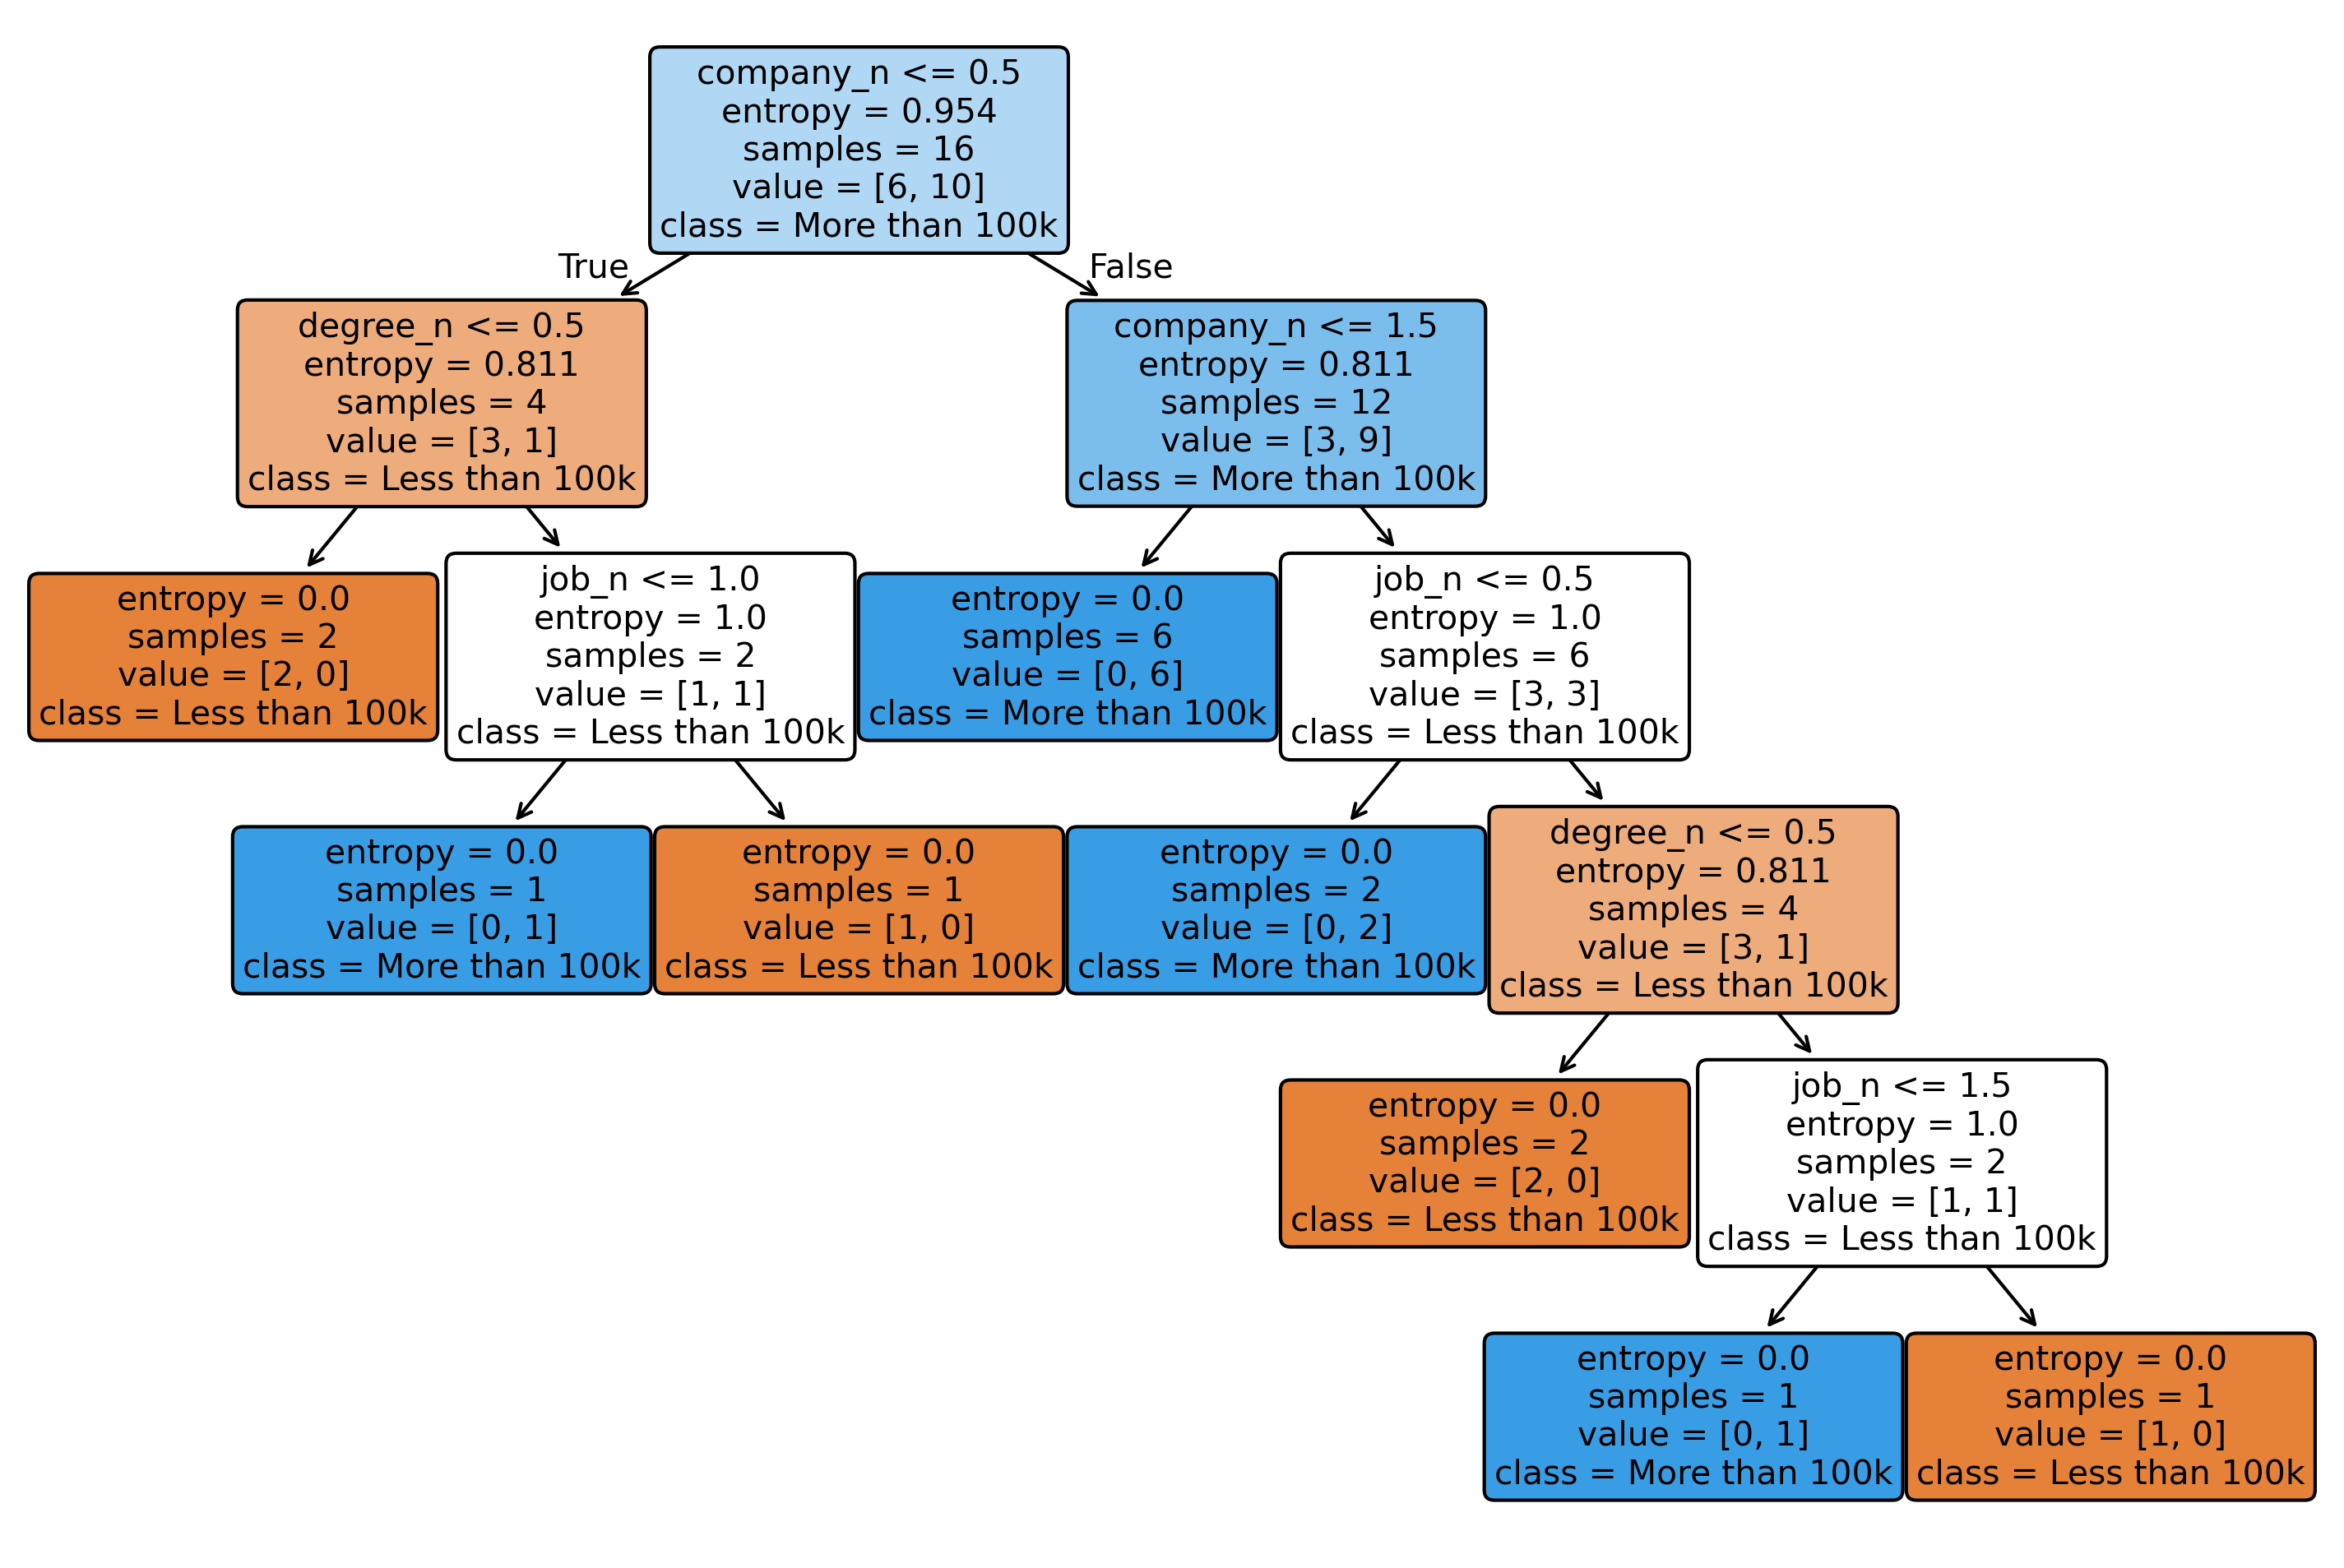

In [85]:
X = df_n.drop(columns="salary_more_then_100k")
y = df_n["salary_more_then_100k"]

#uses entropy (information gain) for splitting tree nodes ie like a activation fn
model = DecisionTreeClassifier(criterion="entropy", random_state=42) # criterions = entropy, gini_impurity
model.fit(X, y)

plt.figure(figsize=(12, 8), dpi=300)
plot_tree(
    model,
    feature_names=X.columns,  # ['company_n', 'job_n', 'degree_n']
    class_names=["Less than 100k", "More than 100k"],  # Labels the outputs (0 and 1)
    filled=True, 
    rounded=True,  
)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature 

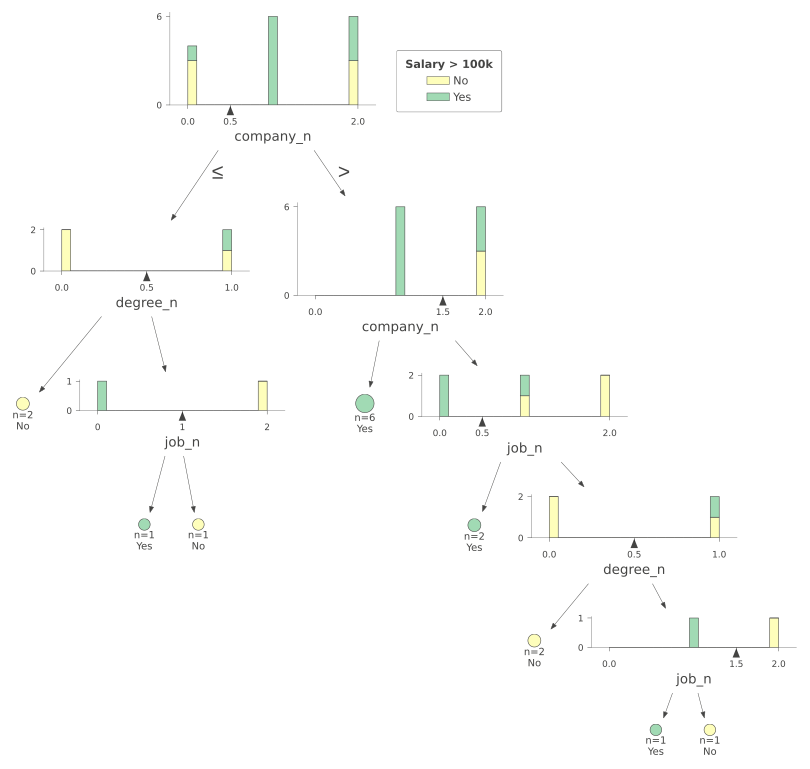

In [98]:
viz_model = dtreeviz.model(
    model,  # trained DecisionTreeClassifier
    X_train=X,  # features (company_n, job_n, degree_n)
    y_train=y,  # target (salary_more_then_100k)
    target_name="Salary > 100k",
    feature_names=list(X.columns),
    class_names=["No", "Yes"]
)

viz_model.view(scale=1.5)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

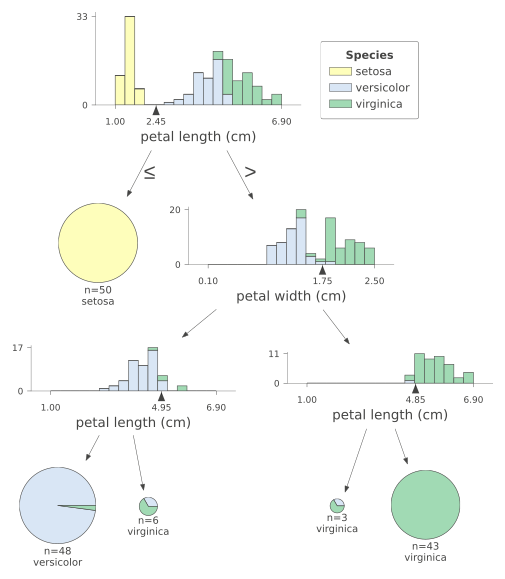

In [2]:
iris = load_iris()
X = iris.data  # Measurements: sepal length, sepal width, etc.
y = iris.target  # Species labels: 0, 1, or 2

model = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
model.fit(X, y)

viz_model = dtreeviz.model(
    model,  # trained DecisionTreeClassifier
    X_train=X,  # features (sepal length, sepal width, etc.)
    y_train=y,  # target (0, 1, or 2)
    target_name="Species",
    feature_names=list(iris.feature_names),
    class_names=list(iris.target_names),  # ['setosa', 'versicolor', 'virginica']
)

viz_model.view(scale=1.5)

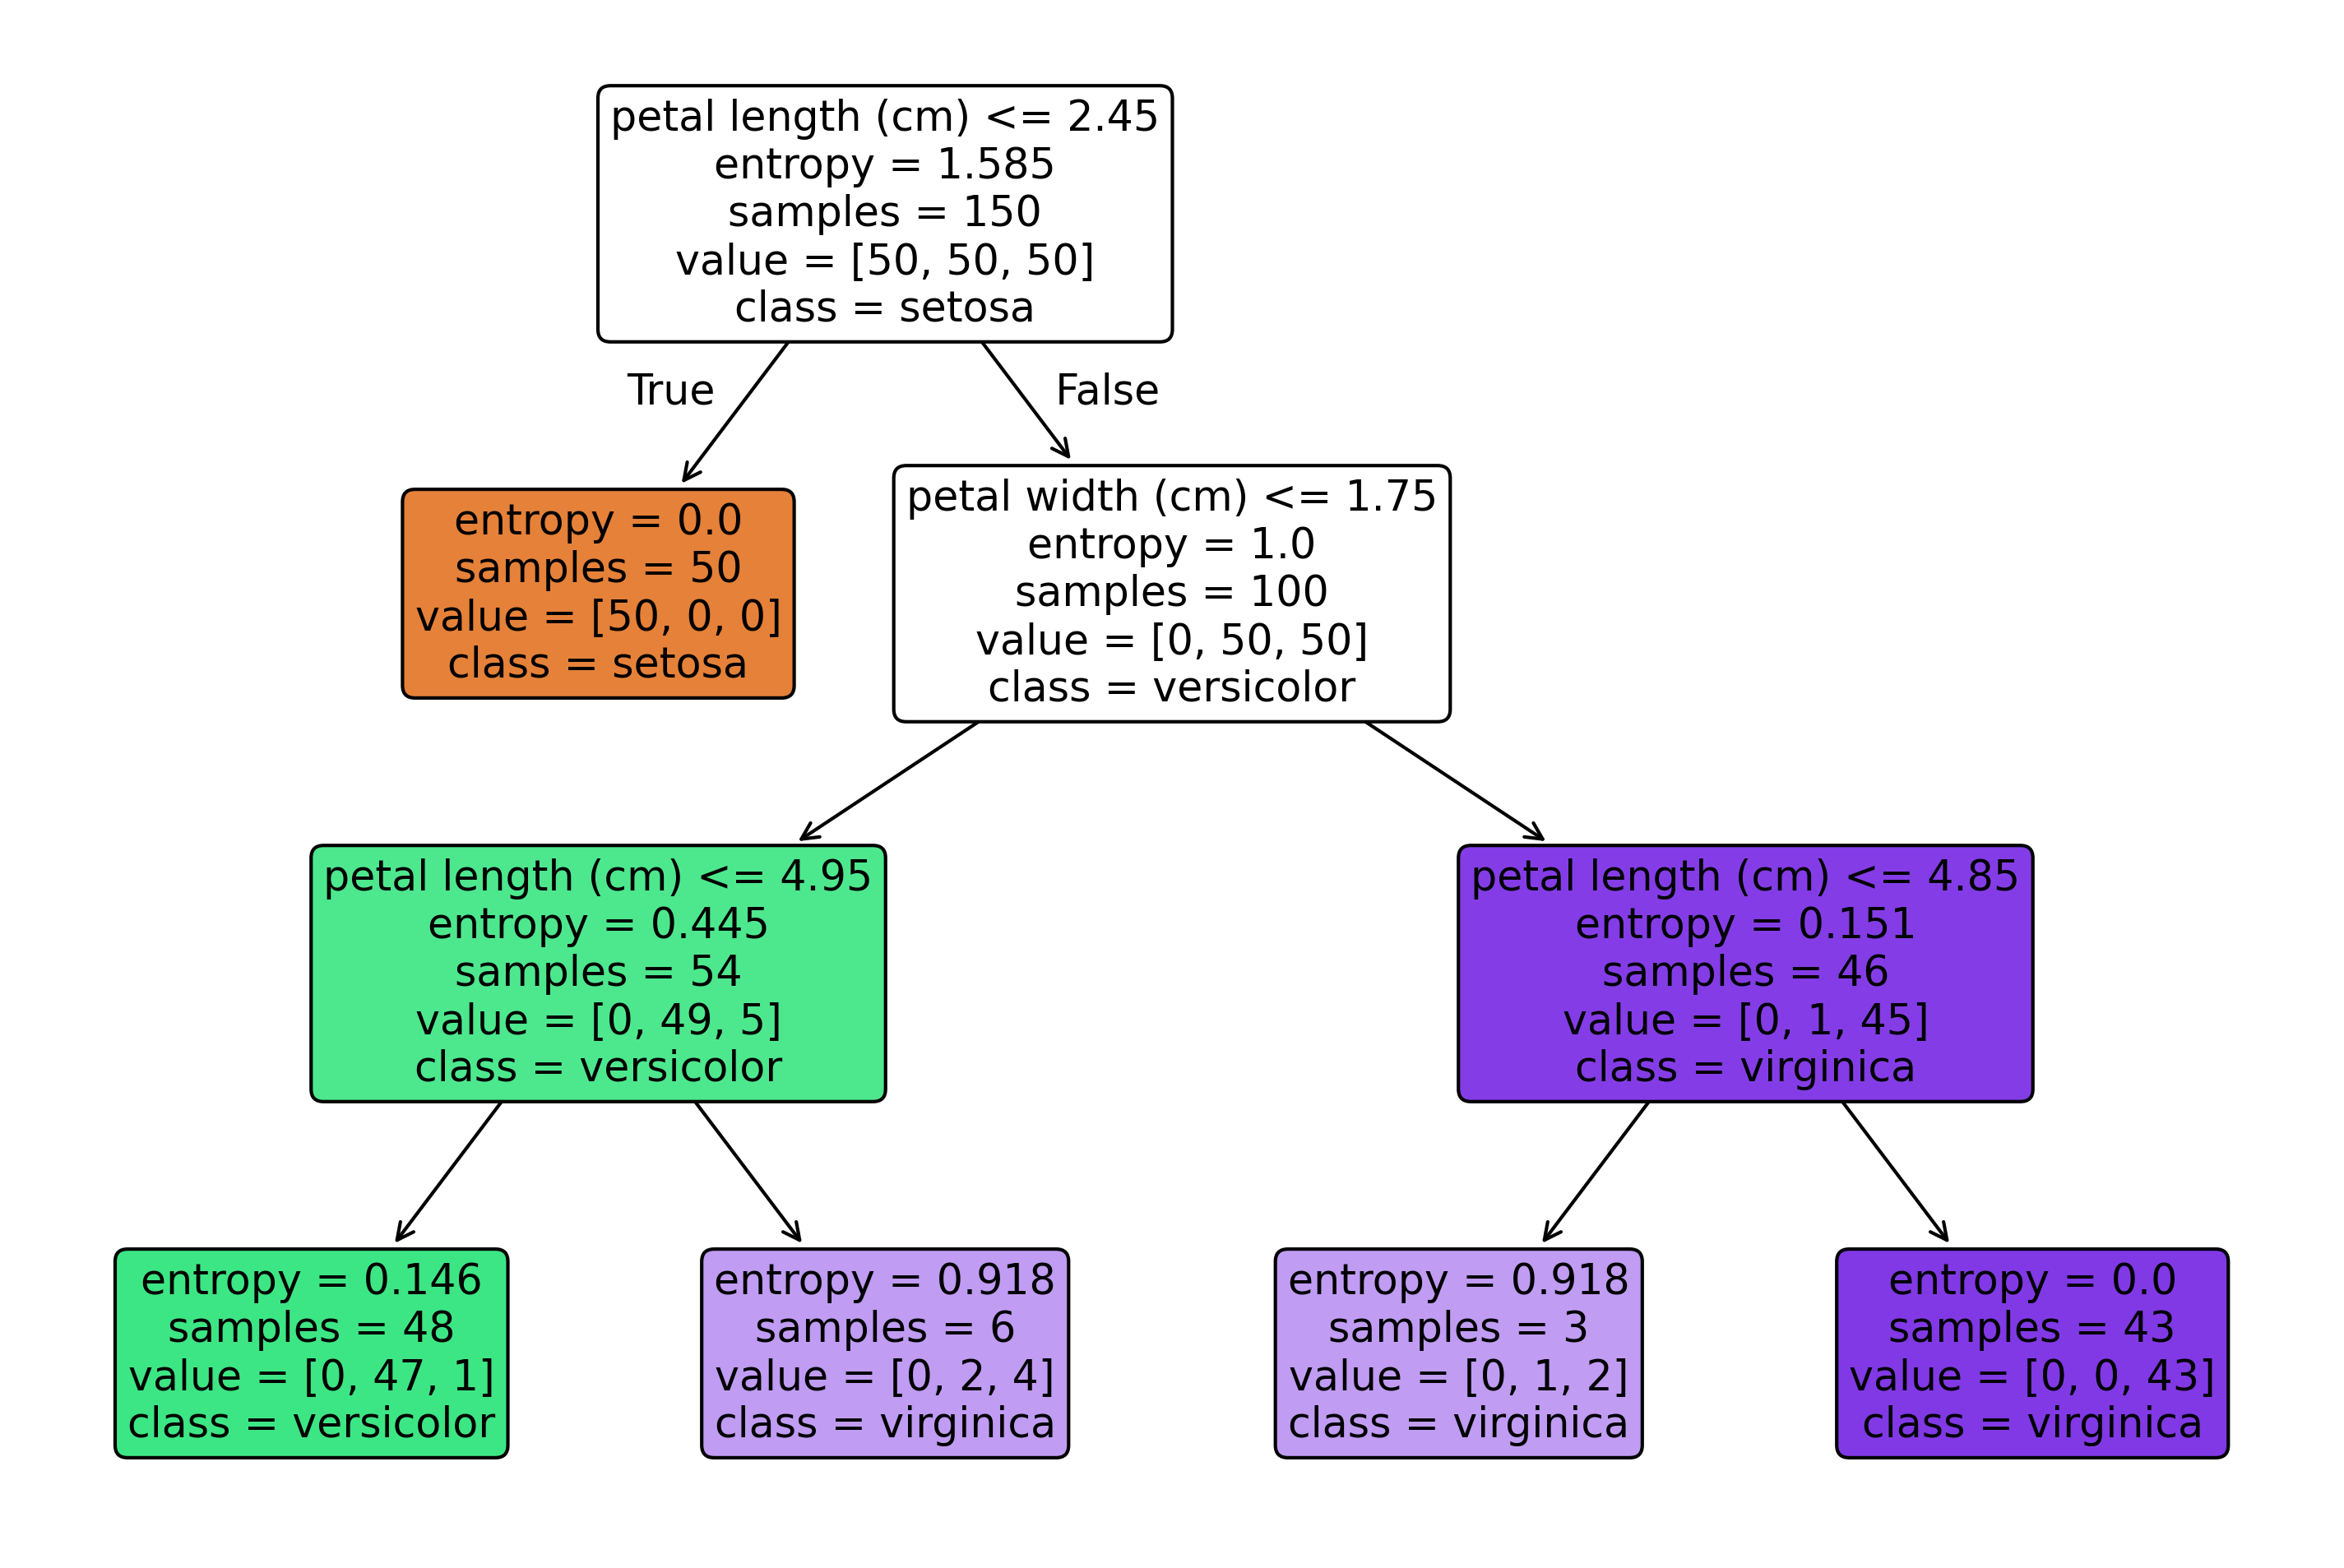

In [3]:
plt.figure(figsize=(12, 8), dpi=300)
plot_tree(
    model,
    feature_names=list(iris.feature_names),  # ['company_n', 'job_n', 'degree_n']
    class_names=list(iris.target_names),  # Labels the outputs (0 and 1)
    filled=True, 
    rounded=True,  
)
plt.show()

Model Accuracy: 100.00%


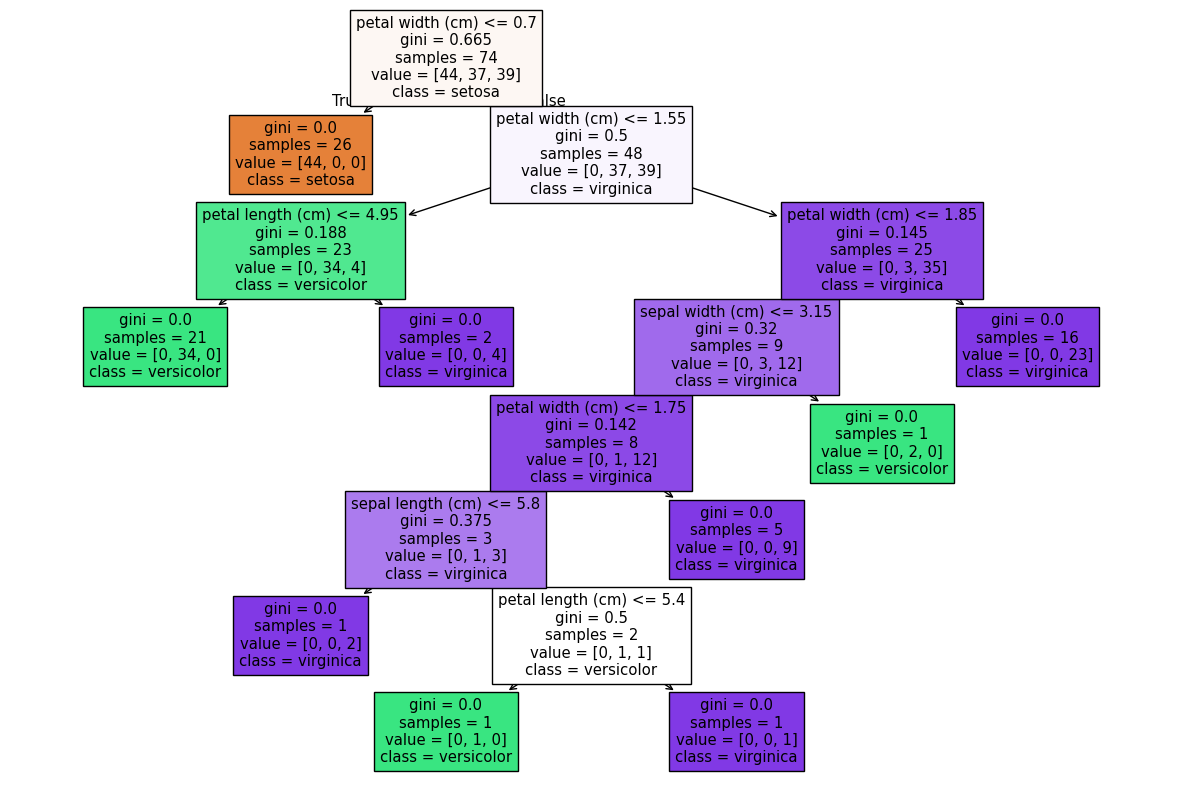

In [7]:
# Random Forest Classifier 
# Each tree is trained on a random subset of the data, When splitting a node, each tree only considers a random subset of the available features.
# It works on the principle of "majority voting": each individual tree in the "forest" gives a classification, and the class that receives the most votes becomes the model's final prediction.

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

#plotting the first decision tree
plt.figure(figsize=(15, 10))
plot_tree(clf.estimators_[0], 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True)
plt.show()

Mean Squared Error: 3552.70


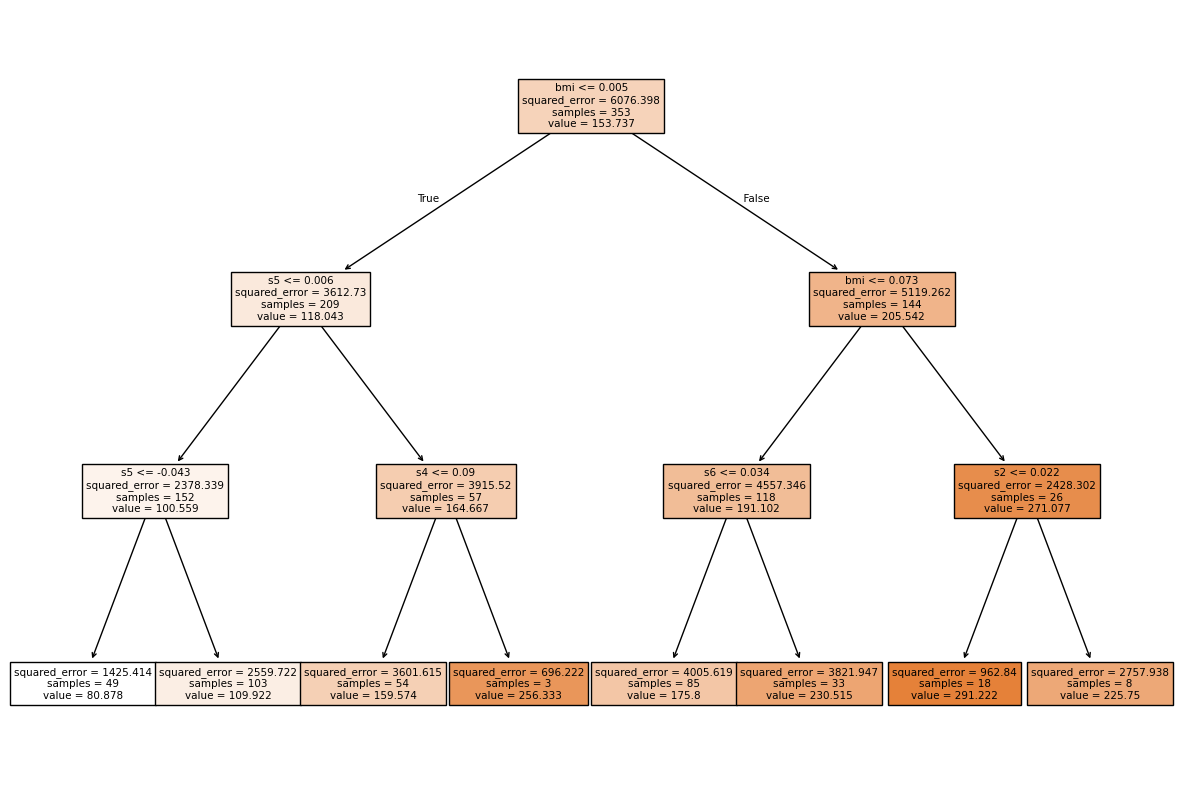

In [103]:
# Decision Tree regressor - for predicting continuous value
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth=3 prevents the tree from becoming too complex (overfitting)
regr = DecisionTreeRegressor(max_depth=3, random_state=42)
regr.fit(X_train, y_train)

predictions = regr.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")

plt.figure(figsize=(15, 10))
plot_tree(regr, feature_names=diabetes.feature_names, filled=True)
plt.show()


In [116]:
print("Features : ", diabetes.feature_names)
print("Data : \n", diabetes.data)
print("Target : \n", diabetes.target)

Features :  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Data : 
 [[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]
Target : 
 [151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  

## 2.4. K-Nearest Neighbour Classifier

In [27]:
# classifying fruit based on its weight and sweetness
X = [[150, 7], [170, 8], [140, 6], [130, 2], [120, 3]]
y = ['Apple', 'Apple', 'Apple', 'Orange', 'Orange']

knn = KNeighborsClassifier(n_neighbors=3, metric='manhattan') 
knn.fit(X, y)

prediction = knn.predict([[145, 5]]) # finds the nearest n=3 neigbours (using euclidian distance) and classify them wrt to majority voting in the time of prediction
prob = knn.predict_proba(X)
print(f"The predicted fruit is: {prediction[0]} with probabilities \n{prob}")

The predicted fruit is: Apple with probabilities 
[[1.         0.        ]
 [1.         0.        ]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.33333333 0.66666667]]


## 2.5. Naives-Byers Classifier

Calculation the final class probabilities for the specific sample day : **[Outlook = Sunny, Temperature = Mild, Humidity = Normal, Windy = Strong]** ie. Sunny=1, Mild=1, Normal=1, Strong=1 where distribution of Sunny, Mild, etc follows a guassian distribution.

The final normalized probability of the **"No"** class given your specific sample conditions (Bayes' formula)

$$P(\text{No} \mid \text{Sunny, Mild, Normal, Strong}) = \frac{P(\text{Sunny}=1 \mid \text{No}) \times P(\text{Mild}=1 \mid \text{No}) \times P(\text{Normal}=1 \mid \text{No}) \times P(\text{Strong}=1 \mid \text{No}) \times P(\text{No})}{\begin{aligned} \left[P(\text{Sunny}=1 \mid \text{No}) \times P(\text{Mild}=1 \mid \text{No}) \times P(\text{Normal}=1 \mid \text{No}) \times P(\text{Strong}=1 \mid \text{No}) \times P(\text{No})\right] \\ + \left[P(\text{Sunny}=1 \mid \text{Yes}) \times P(\text{Mild}=1 \mid \text{Yes}) \times P(\text{Normal}=1 \mid \text{Yes}) \times P(\text{Strong}=1 \mid \text{Yes}) \times P(\text{Yes})\right] \end{aligned}}$$

$$P(\text{No} \mid \text{Sunny, Mild, Normal, Strong}) = \frac{\text{Raw\_Score(No)}}{\text{Raw\_Score(No)} + \text{Raw\_Score(Yes)}}$$

Where the exact raw scores (joint probabilities) for both classes are formulated as follows:

$$\text{Raw\_Score(No)} = P(\text{Sunny}=1 \mid \text{No}) \times P(\text{Mild}=1 \mid \text{No}) \times P(\text{Normal}=1 \mid \text{No}) \times P(\text{Strong}=1 \mid \text{No}) \times P(\text{No})$$

$$\text{Raw\_Score(Yes)} = P(\text{Sunny}=1 \mid \text{Yes}) \times P(\text{Mild}=1 \mid \text{Yes}) \times P(\text{Normal}=1 \mid \text{Yes}) \times P(\text{Strong}=1 \mid \text{Yes}) \times P(\text{Yes})$$

---

$$P(C_i \mid \text{Sample}) = \frac{\text{Raw\_Score}(C_i)}{\sum_{k=1}^{N} \text{Raw\_Score}(C_k)}$$
for more classes than yes/no, where:

* $C_i$ is the specific class you are trying to calculate the percentage for right now (e.g., "Play Football").
* $N$ is the total number of different output categories available.
* $\sum \text{Raw\_Score}(C_k)$ means you calculate the raw score for Class 1, add it to Class 2, add it to Class 3, and so on, until every option is included.

---

Numerical value for any single conditional probability component (where the sample feature value is $x = 1$), the model evaluates the **Gaussian Probability Density Function (PDF)**:

$$P(x = 1 \mid \text{Class}) = \frac{1}{\sqrt{2\pi\sigma_{\text{Class}}^2}} \exp\left( -\frac{(1 - \mu_{\text{Class}})^2}{2\sigma_{\text{Class}}^2} \right)$$

**Variable Definitions:**
*   **$\mu_{\text{Class}}$**: The mathematical mean (average) of that specific feature calculated using only the rows belonging to that historical class in the training dataset.
*   **$\sigma_{\text{Class}}^2$**: The variance (spread) of that specific feature calculated using only the rows belonging to that historical class in the training dataset.

---

| Naive Bayes Variant | What the Input Features ($X$) Look Like | Best Use Case |
| :--- | :--- | :--- |
| `GaussianNB` | Continuous numbers (e.g., 14.2%, 3.14, 180°C). | Physical measurements like heights, weights, or chemical metrics. |
| `CategoricalNB` | Categorical text strings (e.g., `Sunny`, `Hot`, `High`). | Survey data, weather categories, or discrete properties. |
| `BernoulliNB` | **True Binary / Boolean features** (Strictly `0` or `1`). | Text mining where you only care if a word is absent (0) or present (1). |
| `MultinomialNB` | Disconnected text word counts (e.g., the word "free" appears 5 times). | Standard text classification and spam filters. |

In [53]:
# A Naive Bayes classifier is a machine learning algorithm that predicts the category of an item based on probabilities. 
# It is called "naive" because it assumes that every feature of a data point (like the color or shape of a fruit) contributes independently to the final prediction, regardless of any actual correlation between those features.

df = pd.read_csv("./public/tennis.csv")
df.columns = df.columns.str.strip().str.capitalize()
X_text = df.drop(columns=["Play"])
y = df["Play"]

# Convert text categories into numerical columns using One-Hot Encoding (Nominal categorical data in contrast to label encoder for ordinal cat. data)
X_numeric = pd.get_dummies(X_text, dtype=int)
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
prob = model.predict_proba(X_test)
print(f"y_test : {y_test.values} \n")
print(f"y_pred : {y_pred} \n")
print(f"yes & no probabilities for each sample in x_test : \n{prob}")

y_test : <StringArray>
['Yes', 'Yes', 'No', 'Yes', 'No']
Length: 5, dtype: str 

y_pred : ['Yes' 'Yes' 'No' 'Yes' 'Yes'] 

yes & no probabilities for each sample in x_test : 
[[0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [49]:
X_numeric

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,0,0,1,0,1,0,1,0,0,1
1,0,0,1,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1
3,0,1,0,0,0,1,1,0,0,1
4,0,1,0,1,0,0,0,1,0,1
5,0,1,0,1,0,0,0,1,1,0
6,1,0,0,1,0,0,0,1,1,0
7,0,0,1,0,0,1,1,0,0,1
8,0,0,1,1,0,0,0,1,0,1
9,0,1,0,0,0,1,0,1,0,1


# Unsupervised learning algorithms 
## dimensionality reduction, kmeans clustering, hirearchical clustering